In [1]:
from snowflake_info import df_main, df_p1, df_p2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.concat([df_main,df_p1, df_p2], ignore_index=True)


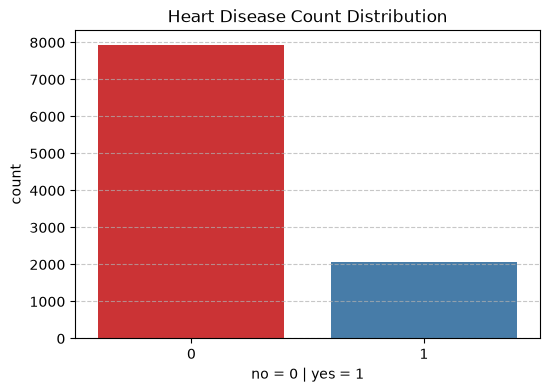

In [2]:
plt.figure(figsize=(6, 4))
sns.countplot(x='heart_disease_status', hue='heart_disease_status', data=df, palette='Set1', legend=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Heart Disease Count Distribution')
plt.xlabel('no = 0 | yes = 1')
plt.ylabel('count')
plt.show()

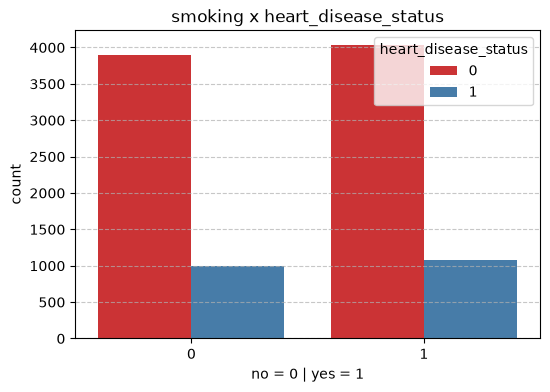

In [3]:
plt.figure(figsize=(6, 4))
sns.countplot(x='smoking', hue='heart_disease_status', data=df, palette='Set1')
plt.title('smoking x heart_disease_status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('no = 0 | yes = 1')
plt.ylabel('count')
plt.show()

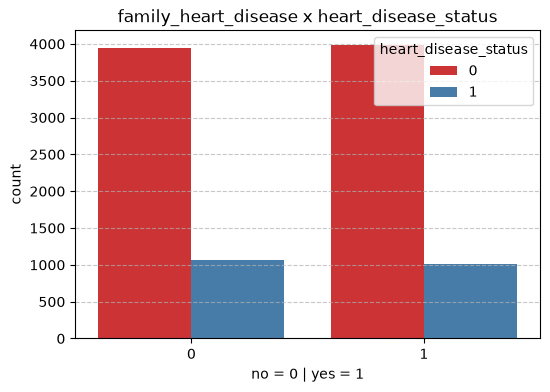

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='family_heart_disease', hue='heart_disease_status', data=df, palette='Set1')
plt.title('family_heart_disease x heart_disease_status')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('no = 0 | yes = 1')
plt.ylabel('count')
plt.show()

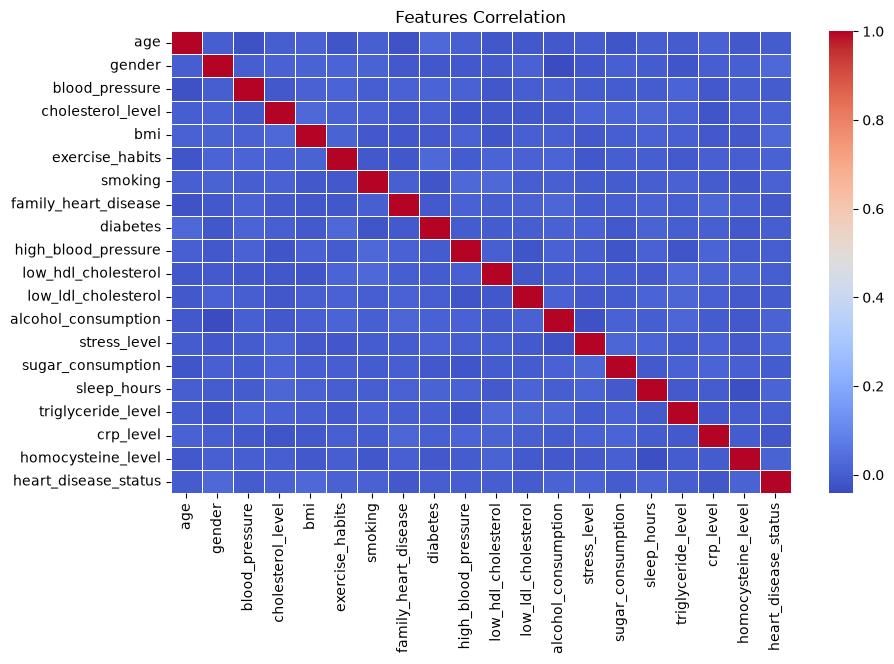

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=False ,cmap='coolwarm',linewidths=0.5)
plt.title('Features Correlation')
plt.show()

In [26]:
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# df_main, df_p1, df_p2
x = df_main.drop(columns='heart_disease_status')
y = df_main['heart_disease_status']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

scalar = StandardScaler()

x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.fit_transform(x_test)

sgd = SGDClassifier(loss='log_loss', max_iter=1000, tol=1e-3, random_state=42)

sgd.partial_fit(x_train_scaled, y_train ,classes=np.array([0, 1]))

y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.83      0.81       808
           1       0.15      0.13      0.14       192

    accuracy                           0.69      1000
   macro avg       0.48      0.48      0.48      1000
weighted avg       0.68      0.69      0.68      1000



In [29]:
# df_p1 | Partial data 1

p1xtrain_scaled = scalar.fit_transform(df_p1.drop(columns='heart_disease_status'))
p1ytrain = df_p1['heart_disease_status']
sgd.partial_fit(p1xtrain_scaled,p1ytrain,classes=np.array([0, 1]))
y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.81      0.81      0.81       808
           1       0.20      0.20      0.20       192

    accuracy                           0.69      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.69      0.69      0.69      1000



In [30]:
# df_p2 | Partial data 2

p1xtrain2_scaled = scalar.fit_transform(df_p2.drop(columns='heart_disease_status'))
p1ytrain2 = df_p2['heart_disease_status']
sgd.partial_fit(p1xtrain2_scaled,p1ytrain2,classes=np.array([0, 1]))
y_pred = sgd.predict(x_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84       808
           1       0.19      0.13      0.15       192

    accuracy                           0.73      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.69      0.73      0.71      1000

